In [150]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [151]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

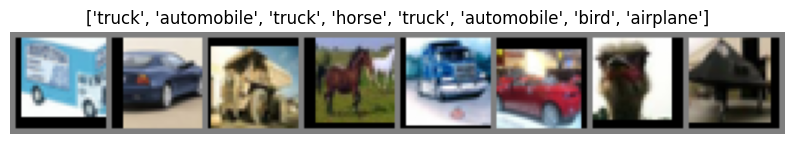

In [152]:
import matplotlib.pyplot as plt
import numpy as np

classes = trainset.classes

def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

# Get a batch
dataiter = iter(trainloader)
images, labels = next(dataiter)

plt.figure(figsize=(10,5))
imshow(torchvision.utils.make_grid(images[:8]))
plt.title([classes[l] for l in labels[:8]])
plt.show()

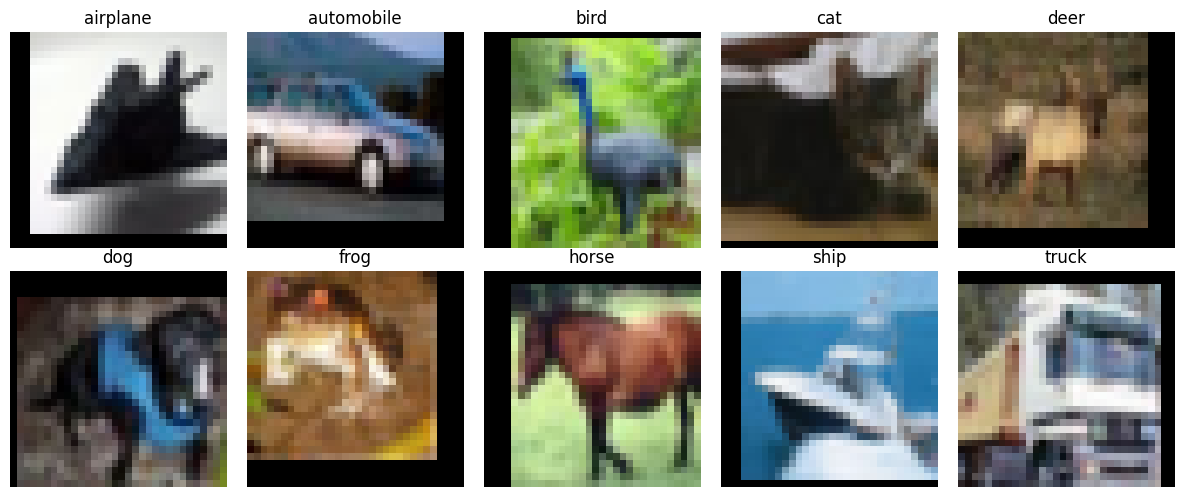

In [153]:
fig, axes = plt.subplots(2, 5, figsize=(12,5))

shown = {i: False for i in range(10)}

for img, label in trainset:
    if not shown[label]:
        row, col = divmod(label, 5)

        img = img / 2 + 0.5
        axes[row, col].imshow(np.transpose(img.numpy(), (1,2,0)))
        axes[row, col].set_title(classes[label])
        axes[row, col].axis('off')

        shown[label] = True

    if all(shown.values()):
        break

plt.tight_layout()
plt.show()

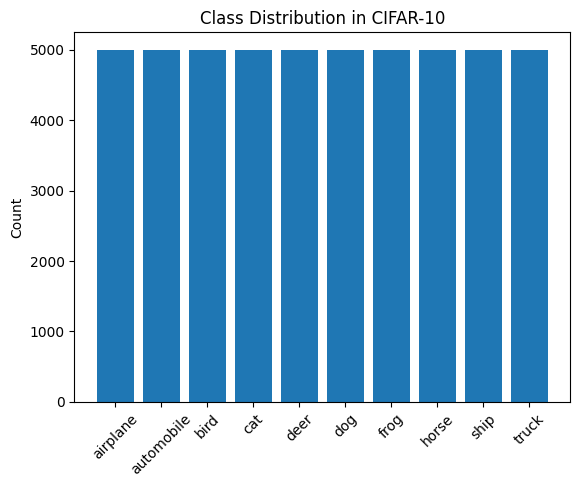

In [154]:
from collections import Counter

labels = [label for _, label in trainset]
counts = Counter(labels)

plt.bar(classes, [counts[i] for i in range(10)])
plt.xticks(rotation=45)
plt.title("Class Distribution in CIFAR-10")
plt.ylabel("Count")
plt.show()

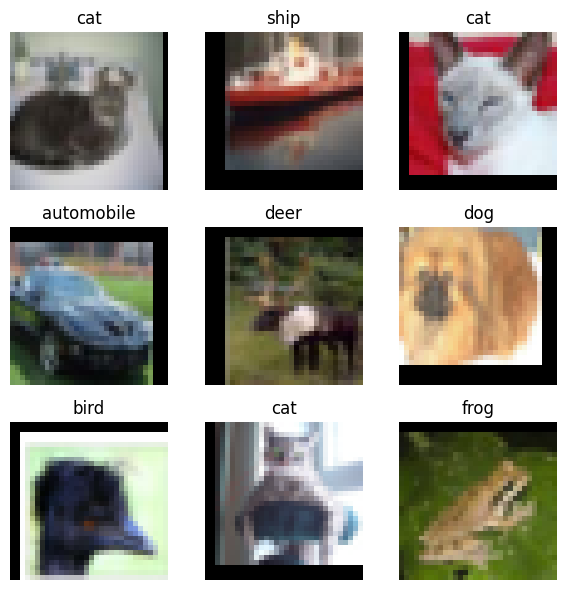

In [155]:
indices = np.random.choice(len(trainset), 9, replace=False)

plt.figure(figsize=(6,6))

for i, idx in enumerate(indices):
    img, label = trainset[idx]

    plt.subplot(3,3,i+1)
    img = img / 2 + 0.5
    plt.imshow(np.transpose(img.numpy(), (1,2,0)))
    plt.title(classes[label])
    plt.axis('off')

plt.tight_layout()
plt.show()

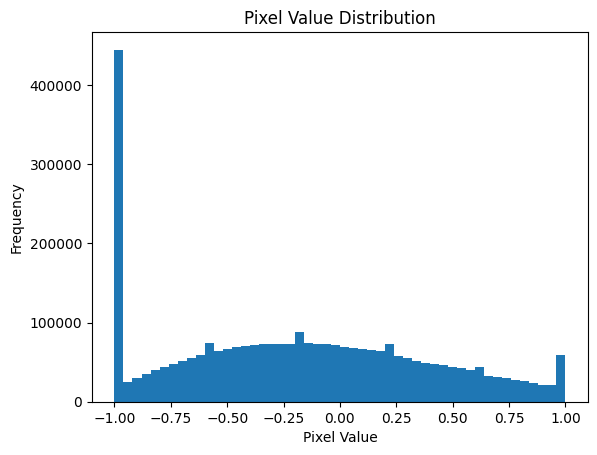

In [156]:
all_pixels = []

for i in range(1000):  # sample subset for speed
    img, _ = trainset[i]
    all_pixels.append(img.numpy().flatten())

all_pixels = np.concatenate(all_pixels)

plt.hist(all_pixels, bins=50)
plt.title("Pixel Value Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

In [157]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.02)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # Bias toward pruning (important)
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features) - 2.0)

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

    def gate_values(self):
        return torch.sigmoid(self.gate_scores)

In [158]:
class HybridNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc1 = PrunableLinear(128*4*4, 256)
        self.fc2 = PrunableLinear(256, 10)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        return self.fc2(x)

    def get_all_gates(self):
        gates = []
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                gates.append(m.gate_values().view(-1))
        return torch.cat(gates)

In [159]:
def sparsity_loss(model):
    total = 0
    for m in model.modules():
        if isinstance(m, PrunableLinear):
            total += torch.sum(m.gate_values())
    return total

In [160]:
def evaluate_accuracy(model):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in testloader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(1)

            total += y.size(0)
            correct += (preds == y).sum().item()

    return 100 * correct / total

def evaluate_accuracy_train(model):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in trainloader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(1)

            total += y.size(0)
            correct += (preds == y).sum().item()

    return 100 * correct / total


def compute_sparsity(model, threshold=1e-2):
    gates = model.get_all_gates().detach().cpu().numpy()
    return (gates < threshold).mean() * 100

In [161]:
def train_model(lambda_val, epochs=15):

    model = HybridNet().to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.CrossEntropyLoss()

    train_acc_list = []
    test_acc_list = []

    for epoch in range(epochs):
        model.train()

        for x, y in trainloader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()

            outputs = model(x)

            cls_loss = criterion(outputs, y)
            sp_loss = sparsity_loss(model)

            loss = cls_loss + lambda_val * sp_loss

            loss.backward()
            optimizer.step()

        #Compute accuracies AFTER each epoch
        train_acc = evaluate_accuracy_train(model)
        test_acc = evaluate_accuracy(model)

        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print(f"Epoch {epoch+1} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

    return model, train_acc_list, test_acc_list

In [162]:
lambdas = [1e-6, 5e-6, 1e-5]

results = []

for lam in lambdas:
    print(f"\n===== Lambda: {lam} =====")

    model, train_acc_list, test_acc_list = train_model(lambda_val=lam)

    acc = evaluate_accuracy(model)
    sparsity = compute_sparsity(model)

    results.append((lam, acc, sparsity))

    print(f"Accuracy: {acc:.2f}%")
    print(f"Sparsity: {sparsity:.2f}%")


===== Lambda: 1e-06 =====
Epoch 1 | Train Acc: 40.62% | Test Acc: 42.40%
Epoch 2 | Train Acc: 47.88% | Test Acc: 49.57%
Epoch 3 | Train Acc: 51.98% | Test Acc: 54.36%
Epoch 4 | Train Acc: 55.47% | Test Acc: 58.73%
Epoch 5 | Train Acc: 58.92% | Test Acc: 60.67%
Epoch 6 | Train Acc: 62.17% | Test Acc: 64.82%
Epoch 7 | Train Acc: 64.23% | Test Acc: 66.34%
Epoch 8 | Train Acc: 64.89% | Test Acc: 66.68%
Epoch 9 | Train Acc: 66.76% | Test Acc: 68.27%
Epoch 10 | Train Acc: 69.40% | Test Acc: 70.69%
Epoch 11 | Train Acc: 69.99% | Test Acc: 71.22%
Epoch 12 | Train Acc: 72.38% | Test Acc: 72.97%
Epoch 13 | Train Acc: 72.43% | Test Acc: 73.50%
Epoch 14 | Train Acc: 74.18% | Test Acc: 74.44%
Epoch 15 | Train Acc: 74.17% | Test Acc: 74.85%
Accuracy: 74.85%
Sparsity: 42.05%

===== Lambda: 5e-06 =====
Epoch 1 | Train Acc: 40.23% | Test Acc: 42.77%
Epoch 2 | Train Acc: 47.30% | Test Acc: 49.39%
Epoch 3 | Train Acc: 50.72% | Test Acc: 53.93%
Epoch 4 | Train Acc: 55.71% | Test Acc: 58.21%
Epoch 5 | Tra

In [163]:
print("\n===== FINAL RESULTS =====")
print("Lambda\t\tAccuracy\tSparsity")

for lam, acc, sparsity in results:
    print(f"{lam:.1e}\t{acc:.2f}%\t\t{sparsity:.2f}%")


===== FINAL RESULTS =====
Lambda		Accuracy	Sparsity
1.0e-06	74.85%		42.05%
5.0e-06	75.27%		44.38%
1.0e-05	74.75%		49.37%


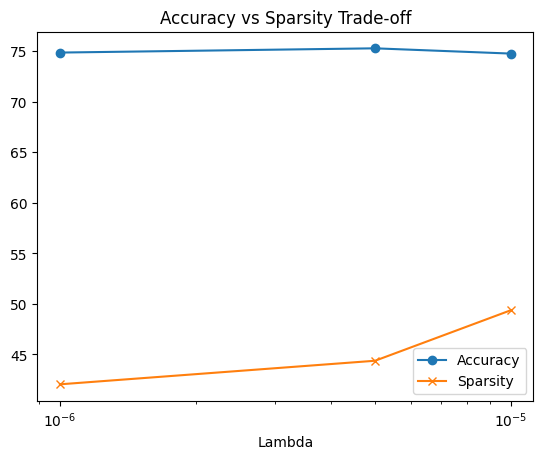

In [164]:
lams = [r[0] for r in results]
accs = [r[1] for r in results]
spars = [r[2] for r in results]

plt.plot(lams, accs, marker='o', label='Accuracy')
plt.plot(lams, spars, marker='x', label='Sparsity')

plt.xscale('log')
plt.xlabel("Lambda")
plt.title("Accuracy vs Sparsity Trade-off")
plt.legend()
plt.show()

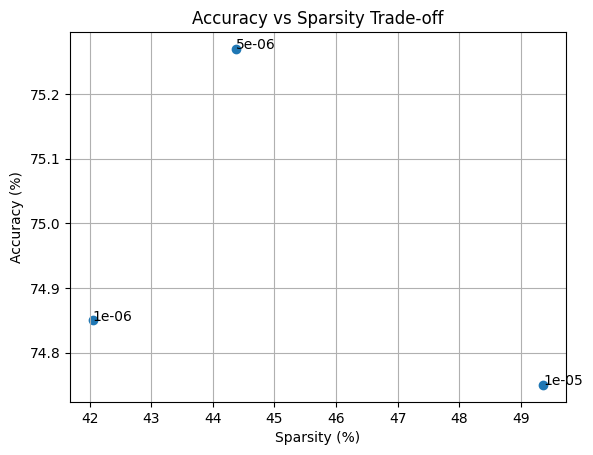

In [165]:
accs = [r[1] for r in results]
spars = [r[2] for r in results]

plt.figure()
plt.scatter(spars, accs)
for i, lam in enumerate([r[0] for r in results]):
    plt.text(spars[i], accs[i], f"{lam:.0e}")

plt.xlabel("Sparsity (%)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Sparsity Trade-off")
plt.grid()
plt.show()

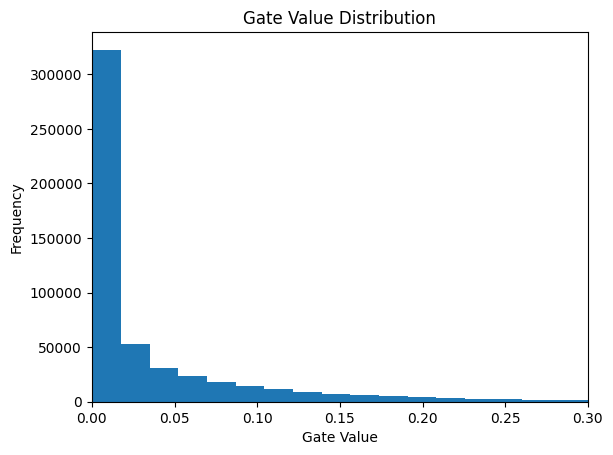

In [166]:
model = model  # use best model
gates = model.get_all_gates().detach().cpu().numpy()

plt.figure()
plt.hist(gates, bins=50)
plt.xlim(0, 0.3)
plt.title("Gate Value Distribution")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.show()

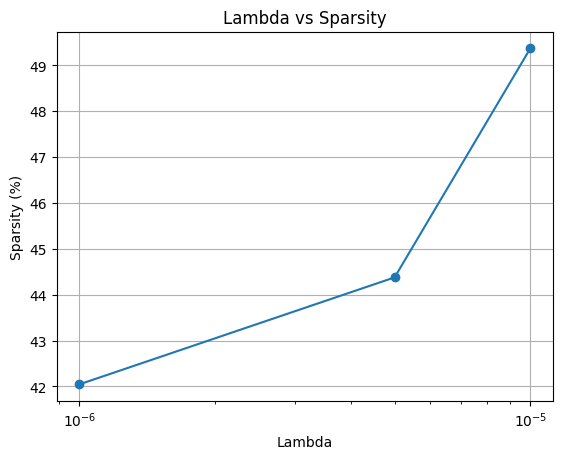

In [167]:
lams = [r[0] for r in results]
spars = [r[2] for r in results]

plt.figure()
plt.plot(lams, spars, marker='o')
plt.xscale('log')
plt.xlabel("Lambda")
plt.ylabel("Sparsity (%)")
plt.title("Lambda vs Sparsity")
plt.grid()
plt.show()

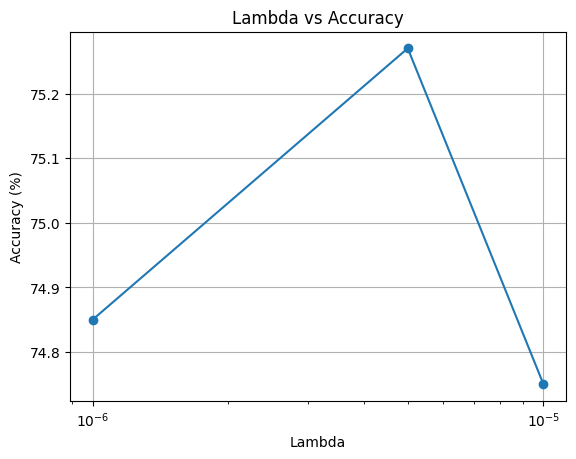

In [168]:
accs = [r[1] for r in results]

plt.figure()
plt.plot(lams, accs, marker='o')
plt.xscale('log')
plt.xlabel("Lambda")
plt.ylabel("Accuracy (%)")
plt.title("Lambda vs Accuracy")
plt.grid()
plt.show()

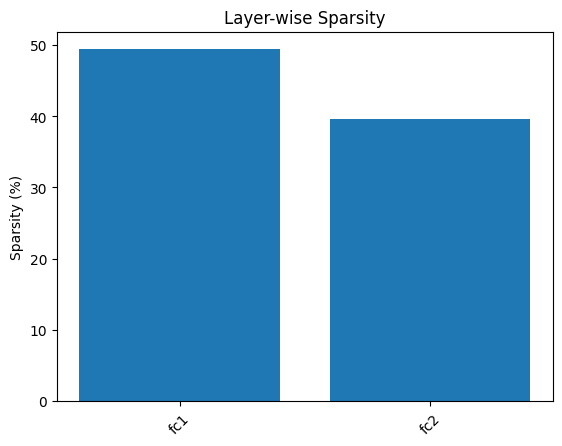

In [169]:
def layer_wise_sparsity(model):
    layer_sparsity = {}

    for name, m in model.named_modules():
        if isinstance(m, PrunableLinear):
            gates = m.gate_values().detach().cpu().numpy()
            sparsity = (gates < 1e-2).mean() * 100
            layer_sparsity[name] = sparsity

    return layer_sparsity


layer_stats = layer_wise_sparsity(model)

plt.bar(layer_stats.keys(), layer_stats.values())
plt.xticks(rotation=45)
plt.ylabel("Sparsity (%)")
plt.title("Layer-wise Sparsity")
plt.show()

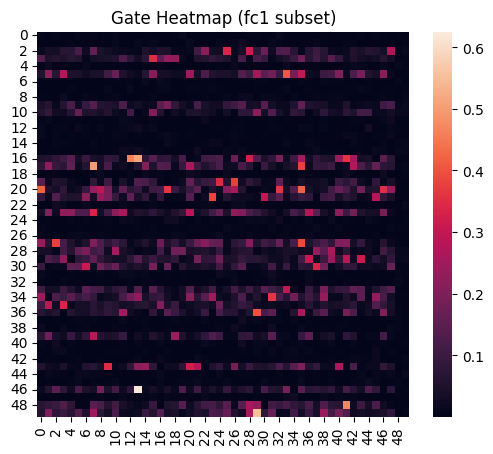

In [170]:
import seaborn as sns

gates = model.fc1.gate_values().detach().cpu().numpy()

plt.figure(figsize=(6,5))
sns.heatmap(gates[:50, :50])  # subset
plt.title("Gate Heatmap (fc1 subset)")
plt.show()

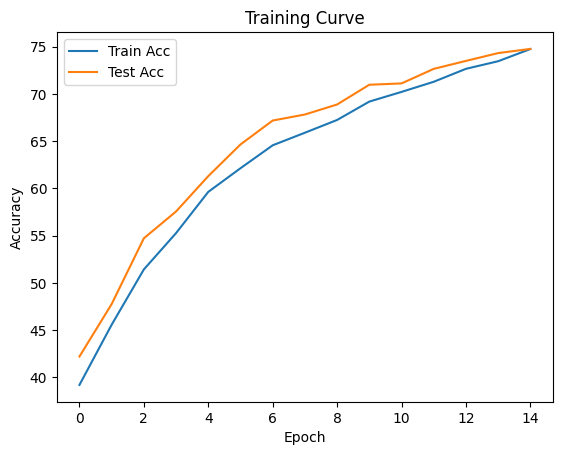

In [171]:
plt.plot(train_acc_list, label="Train Acc")
plt.plot(test_acc_list, label="Test Acc")
plt.legend()
plt.title("Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

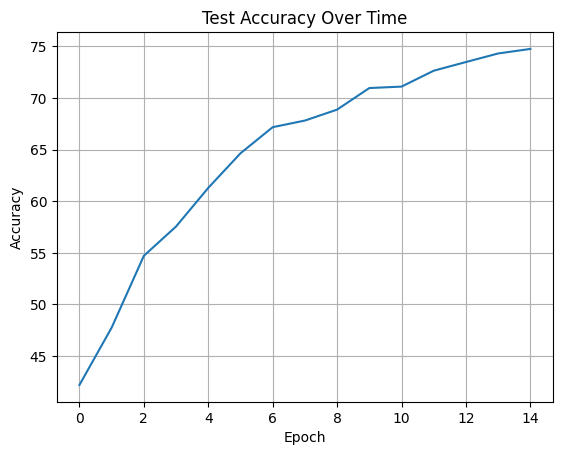

In [172]:
plt.plot(test_acc_list)
plt.title("Test Accuracy Over Time")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.show()